# Scaling Up PolyFEM Matrix Generation

## Goal
Generate even larger golf-ball matrices to stress-test iterative solvers at scale.

## Current largest matrix
- **Source**: `result_250000_plus_trial4/5726041/1_1_A.bin`
- **Size**: 17,178,123 x 17,178,123
- **NNZ**: 756,741,123

## Cost of generation
Running PolyFEM with `Hypre` on a 64-thread server:
- **Preparation** (mesh loading, basis building, etc.): ~5 hours
- **Linear solve** (Cholesky factorization): dominates total time
- **Peak memory**: ~500 GB (out of 1 TB available)
- Cannot run multiple PolyFEM instances in parallel due to memory constraints

## Next steps
Iterative solvers (AMGCL, Hypre, Trilinos) are much cheaper per solve, but the preparation phase (assembly, etc.) is still slow and memory-heavy. Will retry this week to generate more time steps.

# Hypre MPI: Not Actually Parallelizing

## Problem
PolyFEM's polysolve wrapper for Hypre uses `MPI_COMM_WORLD` but does **not** partition matrix rows across processes. In `HypreSolver.cpp`, every MPI process claims ownership of **all rows** `[0, N-1]`:

```cpp
HYPRE_IJMatrixCreate(MPI_COMM_WORLD, 0, rows - 1, 0, cols - 1, &A);
```

HYPRE's IJ interface requires each process to own a **unique, contiguous** block of rows ([HYPRE docs](https://hypre.readthedocs.io/en/latest/ch-ij.html)). The current code violates this, so `mpirun -np 8` gives no speedup — each process redundantly assembles and solves the full system.

## Evidence (golf_ball nv=30116, 8 threads/processes)

| Mode | factorize (s) | solve (s) | total elapse (s) | PCG iters |
|------|:---:|:---:|:---:|:---:|
| **Hypre** (OMP_NUM_THREADS=8) | 0.77 | 1.22 | **1.99** | 49 |
| **Hypre_mpi** (mpirun -np 8) | 0.89 | 2.09 | **2.98** | 29 |

Hypre_mpi is **~50% slower** than OMP Hypre despite fewer PCG iterations (29 vs 49), because each MPI process does redundant work + inter-process communication overhead.

Note: `clock_time` for OMP Hypre is ~10s vs `elapse_time` ~2s (multi-threaded speedup), while for MPI Hypre `clock_time` ≈ `elapse_time` ≈ 3s (no parallelism).

## Upstream status
`polyfem/polysolve` has not updated `HypreSolver.cpp` since Oct 2023 — the same issue exists upstream. Fixing this requires adding proper row partitioning (like HYPRE's official `ex5.c` example) and `MPI_Allgatherv` to collect results.

## Plot below

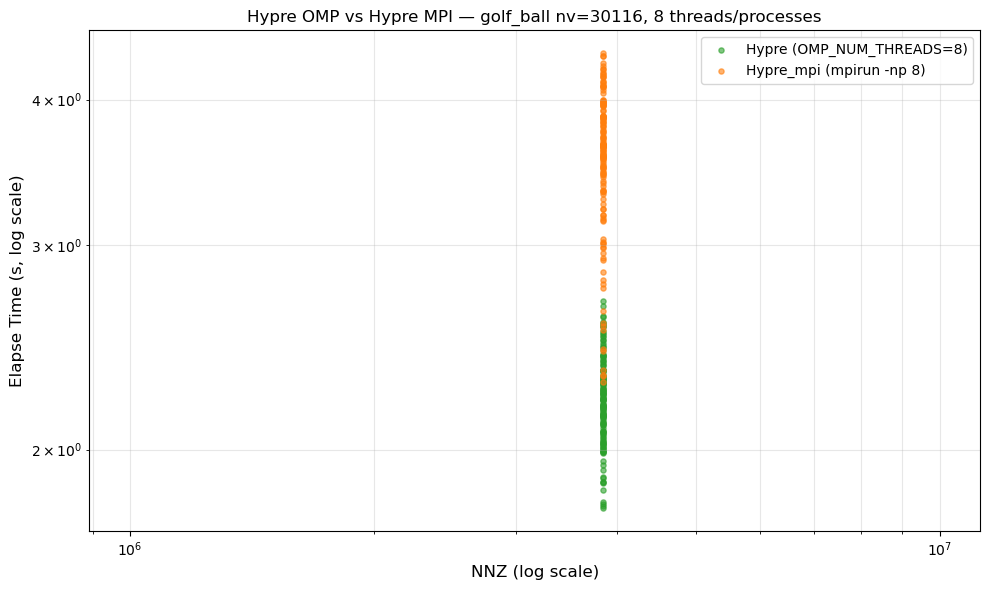

Hypre OMP  mean elapse: 2.214s
Hypre MPI  mean elapse: 3.578s
MPI is 1.62x slower


In [8]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '/u/1/chenyang/benchmark/analysis')
from libs.parser import parse_log_file

log_dir = '/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-1/check_amgcl/golf_ball_8'

hypre_data = parse_log_file(os.path.join(log_dir, 'Hypre_30116.log'), 'Hypre')
hypre_mpi_data = parse_log_file(os.path.join(log_dir, 'Hypre_mpi_30116.log'), 'Hypre')

df_h = pd.DataFrame([{
    'nnz': e['nnz'], 'elapse_time': e['elapse_time'], 'mode': 'Hypre (OMP=8)'
} for e in hypre_data if e.get('nnz') and e.get('elapse_time')])

df_hm = pd.DataFrame([{
    'nnz': e['nnz'], 'elapse_time': e['elapse_time'], 'mode': 'Hypre_mpi (np=8)'
} for e in hypre_mpi_data if e.get('nnz') and e.get('elapse_time')])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_h['nnz'], df_h['elapse_time'], s=14, alpha=0.6, color='#2ca02c', label='Hypre (OMP_NUM_THREADS=8)')
ax.scatter(df_hm['nnz'], df_hm['elapse_time'], s=14, alpha=0.6, color='#ff7f0e', label='Hypre_mpi (mpirun -np 8)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('NNZ (log scale)', fontsize=12)
ax.set_ylabel('Elapse Time (s, log scale)', fontsize=12)
ax.set_title('Hypre OMP vs Hypre MPI — golf_ball nv=30116, 8 threads/processes', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Hypre OMP  mean elapse: {df_h['elapse_time'].mean():.3f}s")
print(f"Hypre MPI  mean elapse: {df_hm['elapse_time'].mean():.3f}s")
print(f"MPI is {df_hm['elapse_time'].mean() / df_h['elapse_time'].mean():.2f}x slower")

Total: 170, Regular Newton: 74, Projected Newton: 96
NNZ (constant across all matrices): 3,838,032


/tmp/ipykernel_3704882/3717661787.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(bp_data, labels=['Regular\nNewton', 'Projected\nNewton'], patch_artist=True, widths=0.5)


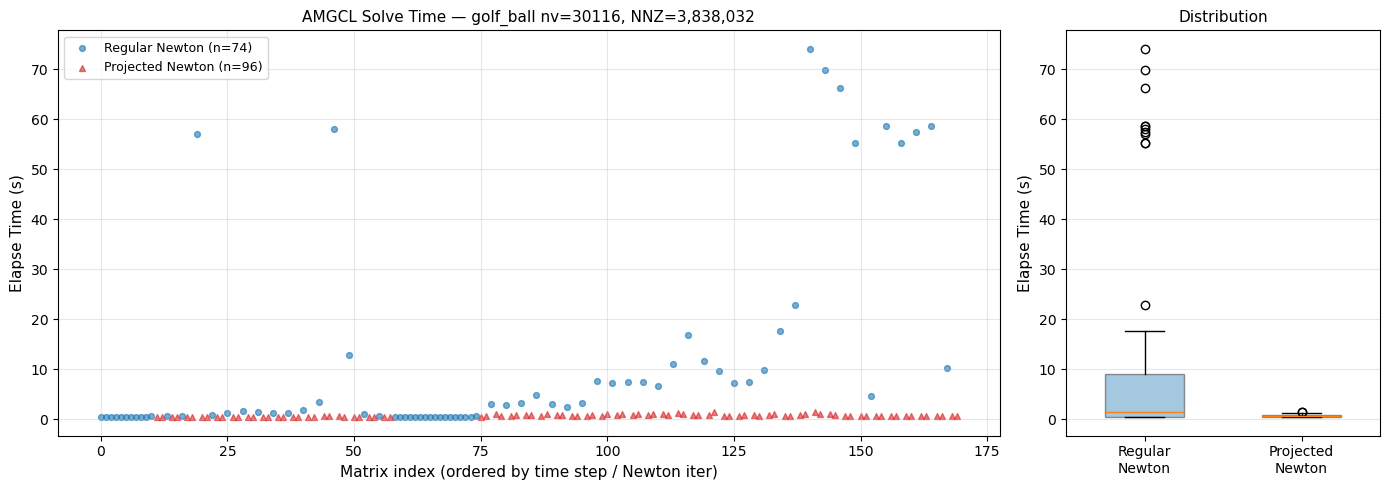


Regular Newton  — mean: 11.359s, median: 1.510s, mean iters: 178.0
Projected Newton — mean: 0.723s, median: 0.656s, mean iters: 7.4


In [9]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

sys.path.insert(0, '/u/1/chenyang/benchmark/analysis')
import libs.parser; importlib.reload(libs.parser)
from libs.parser import parse_log_file

# --- Load AMGCL log ---
log_dir = '/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-1/check_amgcl/golf_ball_8'
amgcl_data = parse_log_file(os.path.join(log_dir, 'AMGCL_30116.log'), 'AMGCL')

# --- Read meta.bin to identify projected Newton ---
def get_projected_newton(bin_A_path):
    meta_path = bin_A_path.replace('_A.bin', '_meta.bin')
    if os.path.exists(meta_path):
        val = np.fromfile(meta_path, dtype=np.int32)
        if len(val) > 0:
            return val[0] == 1
    return False

# --- Build DataFrame ---
rows = []
for i, e in enumerate(amgcl_data):
    if not e.get('nnz') or not e.get('elapse_time'):
        continue
    rows.append({
        'idx': i,
        'nnz': e['nnz'],
        'elapse_time': e['elapse_time'],
        'num_iterations': e.get('num_iterations', np.nan),
        'outer': e.get('outer', np.nan),
        'inner': e.get('inner', np.nan),
        'is_projected_newton': get_projected_newton(e['bin_A']),
    })

df = pd.DataFrame(rows)
df_pn = df[df['is_projected_newton']]
df_reg = df[~df['is_projected_newton']]

print(f"Total: {len(df)}, Regular Newton: {len(df_reg)}, Projected Newton: {len(df_pn)}")
print(f"NNZ (constant across all matrices): {df['nnz'].iloc[0]:,}")

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})

# Left: time vs matrix index (ordered by outer_inner)
ax1.scatter(df_reg['idx'], df_reg['elapse_time'], s=18, alpha=0.6, color='#1f77b4',
            label=f'Regular Newton (n={len(df_reg)})')
ax1.scatter(df_pn['idx'], df_pn['elapse_time'], s=18, alpha=0.6, color='#d62728', marker='^',
            label=f'Projected Newton (n={len(df_pn)})')
ax1.set_xlabel('Matrix index (ordered by time step / Newton iter)', fontsize=11)
ax1.set_ylabel('Elapse Time (s)', fontsize=11)
ax1.set_title(f'AMGCL Solve Time — golf_ball nv=30116, NNZ={df["nnz"].iloc[0]:,}', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: box plot comparison
bp_data = [df_reg['elapse_time'].values, df_pn['elapse_time'].values]
bp = ax2.boxplot(bp_data, labels=['Regular\nNewton', 'Projected\nNewton'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#1f77b4'); bp['boxes'][0].set_alpha(0.4)
bp['boxes'][1].set_facecolor('#d62728'); bp['boxes'][1].set_alpha(0.4)
ax2.set_ylabel('Elapse Time (s)', fontsize=11)
ax2.set_title('Distribution', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# --- Summary ---
print(f"\nRegular Newton  — mean: {df_reg['elapse_time'].mean():.3f}s, median: {df_reg['elapse_time'].median():.3f}s, mean iters: {df_reg['num_iterations'].mean():.1f}")
print(f"Projected Newton — mean: {df_pn['elapse_time'].mean():.3f}s, median: {df_pn['elapse_time'].median():.3f}s, mean iters: {df_pn['num_iterations'].mean():.1f}")

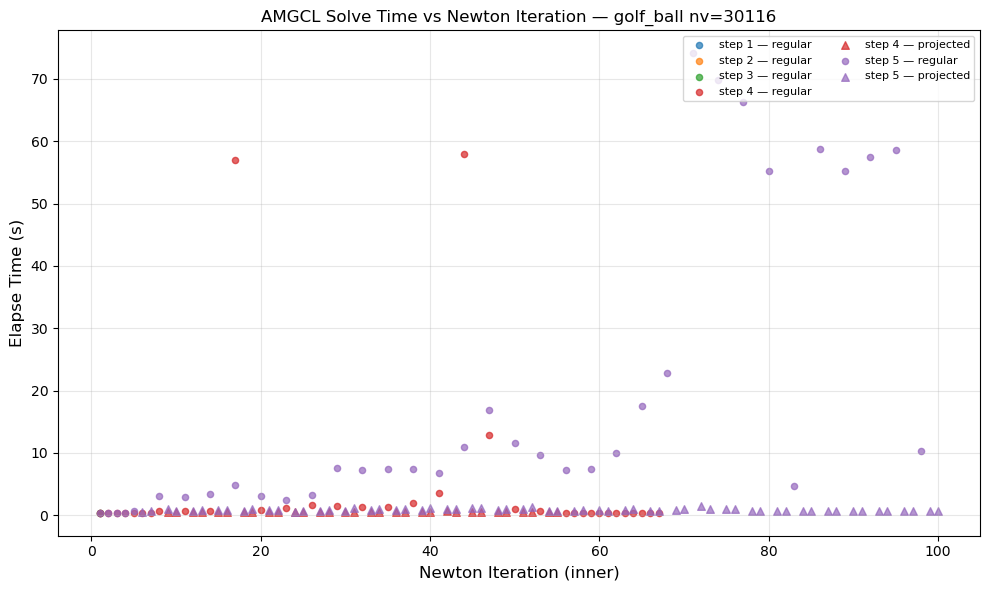

In [10]:
# --- Plot: elapse_time vs Newton iteration (inner), per outer step ---
fig, ax = plt.subplots(figsize=(10, 6))

outer_steps = sorted(df['outer'].unique())
cmap = plt.cm.tab10

for oi, outer in enumerate(outer_steps):
    d = df[df['outer'] == outer]
    d_reg = d[~d['is_projected_newton']]
    d_pn = d[d['is_projected_newton']]

    color = cmap(oi)
    if not d_reg.empty:
        ax.scatter(d_reg['inner'], d_reg['elapse_time'], s=20, alpha=0.7, color=color,
                   label=f'step {int(outer)} — regular')
    if not d_pn.empty:
        ax.scatter(d_pn['inner'], d_pn['elapse_time'], s=30, alpha=0.7, color=color, marker='^',
                   label=f'step {int(outer)} — projected')

ax.set_xlabel('Newton Iteration (inner)', fontsize=12)
ax.set_ylabel('Elapse Time (s)', fontsize=12)
ax.set_title('AMGCL Solve Time vs Newton Iteration — golf_ball nv=30116', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

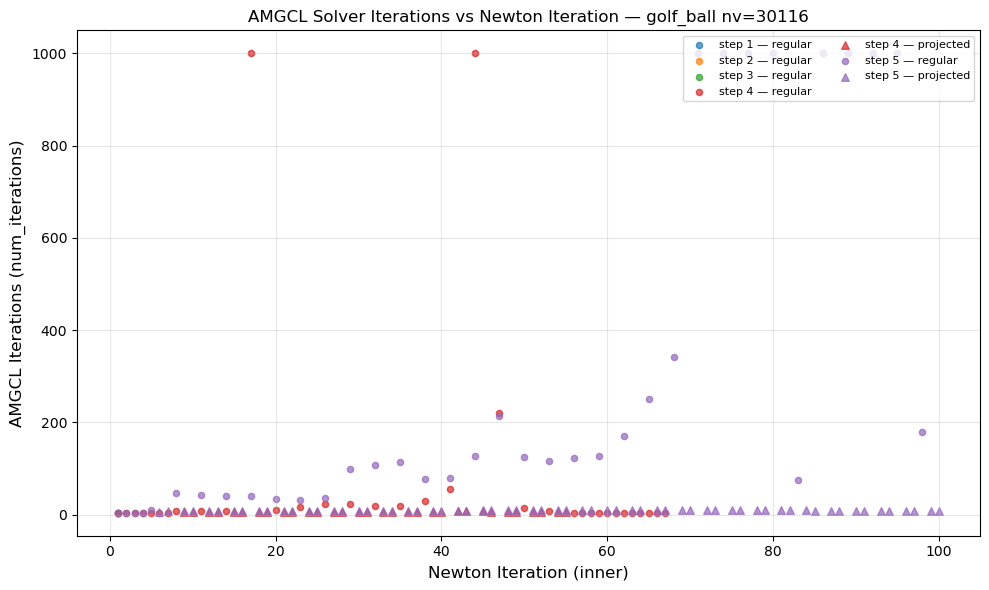

In [11]:
# --- Plot: AMGCL iterations (num_iterations) vs Newton iteration (inner) ---
fig, ax = plt.subplots(figsize=(10, 6))

for oi, outer in enumerate(outer_steps):
    d = df[df['outer'] == outer]
    d_reg = d[~d['is_projected_newton']]
    d_pn = d[d['is_projected_newton']]

    color = cmap(oi)
    if not d_reg.empty:
        ax.scatter(d_reg['inner'], d_reg['num_iterations'], s=20, alpha=0.7, color=color,
                   label=f'step {int(outer)} — regular')
    if not d_pn.empty:
        ax.scatter(d_pn['inner'], d_pn['num_iterations'], s=30, alpha=0.7, color=color, marker='^',
                   label=f'step {int(outer)} — projected')

ax.set_xlabel('Newton Iteration (inner)', fontsize=12)
ax.set_ylabel('AMGCL Iterations (num_iterations)', fontsize=12)
ax.set_title('AMGCL Solver Iterations vs Newton Iteration — golf_ball nv=30116', fontsize=12)
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()